In [312]:
import dataclasses
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [314]:
@dataclasses.dataclass
class Metrics:
    config: dict
    site_msds: np.ndarray
    separation_scores: np.ndarray
    separation_histories: np.ndarray

In [315]:
task_ids = ["task-13", "task-11"]

conds_metrics = {}

for task_id in task_ids:
    with h5py.File(f"{task_id}/_outputs/metrics-nocen.h5", "r") as store:
        conds_metrics[task_id] = Metrics(
            config=json.loads(store["config"][()]),
            site_msds=store["site_msds"][:, :11, :],
            separation_scores=store["separation_scores"][:],
            separation_histories=store["separation_histories"][:],
        )

In [316]:
@dataclasses.dataclass
class CondConfig:
    color: any
    label: str

conds_config = {
    "task-1": CondConfig(color="k", label="control"),
    "task-2": CondConfig(color="r", label="Δcohesin (2)"),
    "task-3": CondConfig(color="k", label="control"),
    "task-4": CondConfig(color="k", label="control"),
    "task-5": CondConfig(color="k", label="control"),
    "task-6": CondConfig(color="k", label="control"),
    "task-7": CondConfig(color="k", label="control"),
    "task-8": CondConfig(color="m", label="Δcohesin (8)"),
    "task-9": CondConfig(color="k", label="control"),
    "task-10": CondConfig(color="k", label="control"),
    "task-11": CondConfig(color="b", label="Δcohesin (11)"),
    "task-12": CondConfig(color="k", label="control"),
    "task-13": CondConfig(color="k", label="control"),
    "task-14": CondConfig(color="r", label="Δcohesin (14)"),
    "task-15": CondConfig(color="k", label="control"),
}

In [317]:
@dataclasses.dataclass
class MSDAnalysis:
    lags: np.ndarray
    means: np.ndarray
    stds: np.ndarray
    alpha: float
    beta: float

In [318]:
conds_msds = {}

for task_id, metrics in conds_metrics.items():
    config = metrics.config
    sampling_config = config["sampling"]
    phase_overrides = sampling_config["phases"][-1]
    phase_config = {**sampling_config, **phase_overrides}
    frame_interval = phase_config["timestep"] * phase_config["sampling_interval"]

    lags = np.arange(metrics.site_msds.shape[1]) * frame_interval
    msd_samples = einops.rearrange(metrics.site_msds, "r t s -> (r s) t")
    msd_mean = msd_samples.mean(axis=0)
    msd_std = msd_samples.std(axis=0)

    x = lags
    y = msd_mean
    alpha, beta = fit_power_law(x, y)

    conds_msds[task_id] = MSDAnalysis(
        lags=lags,
        means=msd_mean,
        stds=msd_std,
        alpha=alpha,
        beta=beta,
    )

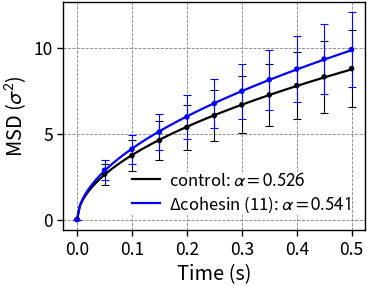

In [319]:
fig, ax = plt.subplots(figsize=(1.9, 1.5))

for task_id, msd in conds_msds.items():
    cond_config = conds_config[task_id]
    color = cond_config.color
    label = cond_config.label

    x = msd.lags
    y = msd.means
    y_err = msd.stds
    ax.errorbar(x, y, y_err, color=color, linewidth=0, elinewidth=0.4, capsize=1.3, capthick=0.4, zorder=2)
    ax.scatter(x, y, s=4, ec="none", fc=color, zorder=3)

    x = np.linspace(msd.lags[0], msd.lags[-1], num=100)
    y = x**msd.alpha * msd.beta
    s = f"{label}: " r"$ \alpha = %.3f $" % msd.alpha
    ax.plot(x, y, lw=0.8, color=color, label=s)

ax.grid(True, zorder=1)
ax.legend(frameon=True)
ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")

pass

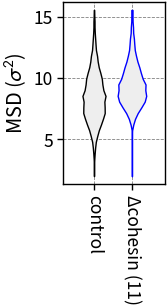

In [320]:
reference_lag = 10
msd_bins = np.linspace(2, 16, num=31)
density_scale = 1.5

fig, ax = plt.subplots(figsize=(0.9, 1.6))

for i, (task_id, metrics) in enumerate(conds_metrics.items()):
    color = conds_config[task_id].color
    msds = metrics.site_msds[:, reference_lag, :].ravel()

    density, _ = np.histogram(
        msds,
        bins=msd_bins,
        density=True,
    )
    ax.fill_betweenx(
        msd_bins[:-1],
        i + density * density_scale,
        i - density * density_scale,
        ec=color,
        fc="#eee",
        zorder=2,
    )

ax.margins(x=0.3)

ax.grid(True, zorder=1)

ax.set_xticks(np.arange(len(conds_metrics)))
ax.set_xticklabels(
    [conds_config[key].label for key in conds_metrics.keys()],
    rotation=-90,
)
ax.set_ylabel(r"MSD ($ \sigma^2 $)")

pass

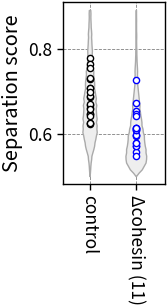

In [326]:
score_bins = np.linspace(0.5, 0.9, num=51)

fig, ax = plt.subplots(figsize=(0.9, 1.6))

for i, (config_id, metrics) in enumerate(conds_metrics.items()):
    color = conds_config[config_id].color

    x = np.full_like(metrics.separation_scores, i)
    y = metrics.separation_scores
    #ax.scatter(x, y, s=3, fc=color, ec="none", zorder=3)
    ax.scatter(x, y, s=5, fc="w", ec=color, zorder=3)

    density_scale = 0.03

    density, _ = np.histogram(
        metrics.separation_histories.ravel(),
        bins=score_bins,
        density=True,
    )
    ax.fill_betweenx(
        score_bins[:-1],
        i + density * density_scale,
        i - density * density_scale,
        ec="#aaa",
        fc="#eee",
        zorder=2,
    )

ax.margins(x=0.3)

ax.grid(True, zorder=1)

ax.set_xticks(np.arange(len(conds_metrics)))
ax.set_xticklabels(
    [
        conds_config[key].label for key in conds_metrics.keys()
    ],
    rotation=-90,
)
#ax.set_ylim(0.48, 0.92)
ax.set_ylabel("Separation score")

pass

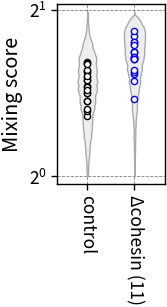

In [330]:
score_bins = np.linspace(1, 2, num=51)

fig, ax = plt.subplots(figsize=(0.9, 1.6))

for i, (config_id, metrics) in enumerate(conds_metrics.items()):
    color = conds_config[config_id].color

    x = np.full_like(metrics.separation_scores, i)
    y = 1 / metrics.separation_scores
    ax.scatter(x, y, s=5, fc="w", ec=color, zorder=3)

    density_scale = 0.1

    density, _ = np.histogram(
        1 / metrics.separation_histories.ravel(),
        bins=score_bins,
        density=True,
    )
    ax.fill_betweenx(
        score_bins[:-1],
        i + density * density_scale,
        i - density * density_scale,
        ec="#aaa",
        fc="#eee",
        zorder=2,
    )

ax.margins(x=0.3)

ax.grid(True, zorder=1)

ax.set_xticks(np.arange(len(conds_metrics)))
ax.set_xticklabels(
    [
        conds_config[key].label for key in conds_metrics.keys()
    ],
    rotation=-90,
)
ax.set_ylabel("Mixing score")

pass

In [322]:
for config_id, metrics in conds_metrics.items():
    orders = np.argsort(metrics.separation_scores)
    median_instance = orders[len(orders) // 2]
    top_instance = orders[-1]
    print(config_id, median_instance, top_instance)

task-13 3 6
task-11 14 1
